# 02 — ML Pipeline Multiclass

Full model selection, oversampling comparison, OOD evaluation, and interpretability for WoT and Dota at best granularity (loaded from registry).

In [26]:
# imports
import warnings, json
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.base import clone
from sklearn.metrics import classification_report
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler
import joblib

import sys
sys.path.insert(0, str(Path('../..').resolve()))
from src.loaders import load_wot, load_dota, load_combined
from src.pipelines import build_pipe
from src.scoring import cv_score, holdout_score, ood_score, append_registry, make_f1_scorer
from src.label_schemes import WOT_CLASS_NAMES, DOTA_CLASS_NAMES

# config
CONFIG = {
    'seed': 7524,
    'cv_folds': 5,
    'text_col': 'clean_message',
    'label_col': 'label',
    'optuna_trials': 30,
    'registry_path': Path('../../data/results/results_registry.csv'),
    'models_dir': Path('../../models'),
}

# reproducibility
seed = CONFIG['seed']
cv = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=seed)
np.random.seed(seed)
CONFIG['models_dir'].mkdir(exist_ok=True)

# load best granularity from notebook 01 registry
wot_best_n = 2
dota_best_n = 2
print(f'WoT best granularity: {wot_best_n} classes')
print(f'Dota best granularity: {dota_best_n} classes')

WoT best granularity: 2 classes
Dota best granularity: 2 classes


## Section 2: Model Selection

In [8]:
# model selection with Optuna tuning on F1 (recall-weighted)
# RandomOverSampler used for all models - chosen in notebook 01
# n_jobs=1 inside Optuna on Windows - multiprocessing spawn overhead too high

def run_model_selection(game: str, load_fn, n_classes: int):
    # load and binarise - label > 0 means toxic
    train_df = load_fn('train').copy()
    train_df[CONFIG['label_col']] = (train_df[CONFIG['label_col']].astype(int) > 0).astype(int)

    # split into y train and x train
    X_train = train_df[CONFIG['text_col']]
    y_train = train_df[CONFIG['label_col']]

    # list for model comparison
    models_comparison = []

    # Logistic Regression - CV across 30 C values, optimised on F1
    print(f'[{game}] Logistic Regression ...')
    lr_pipe = build_pipe(
        LogisticRegressionCV(Cs=30, cv=cv, scoring= make_f1_scorer(n_classes), max_iter=2000, random_state=seed, n_jobs=-1),
        oversampler=RandomOverSampler(random_state=seed)
    )
    lr_scores = cv_score(lr_pipe, X_train, y_train, cv=cv)
    models_comparison.append({'Model': 'Logistic Regression', **lr_scores})

    # Naive Bayes - Optuna tunes alpha
    print(f'[{game}] Naive Bayes (Optuna) ...')
    def nb_objective(trial):
        p = {'clf__alpha': trial.suggest_float('clf__alpha', 0.001, 2.0, log=True)}
        p_pipe = build_pipe(MultinomialNB(), oversampler=RandomOverSampler(random_state=seed))
        p_pipe.set_params(**p)
        return cross_val_score(p_pipe, X_train, y_train, cv=cv, scoring= make_f1_scorer(n_classes), n_jobs=1).mean()

    study_nb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))
    study_nb.optimize(nb_objective, n_trials=CONFIG['optuna_trials'])
    nb_pipe = build_pipe(MultinomialNB(), oversampler=RandomOverSampler(random_state=seed))
    nb_pipe.set_params(**study_nb.best_params)
    nb_scores = cv_score(nb_pipe, X_train, y_train, cv=cv)
    models_comparison.append({'Model': 'Naive Bayes', **nb_scores})

    # LinearSVC - Optuna tunes C
    print(f'[{game}] LinearSVC (Optuna) ...')
    def svc_objective(trial):
        C = trial.suggest_float('clf__C', 0.01, 10.0, log=True)
        p_pipe = build_pipe(
            LinearSVC(C=C, max_iter=2000, tol=1e-3, random_state=seed),
            oversampler=RandomOverSampler(random_state=seed)
        )
        return cross_val_score(p_pipe, X_train, y_train, cv=cv, scoring=make_f1_scorer(n_classes), n_jobs=1).mean()

    study_svc = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))
    study_svc.optimize(svc_objective, n_trials=CONFIG['optuna_trials'])
    svc_pipe = build_pipe(
        LinearSVC(C=study_svc.best_params['clf__C'], max_iter=2000, tol=1e-3, random_state=seed),
        oversampler=RandomOverSampler(random_state=seed)
    )
    svc_scores = cv_score(svc_pipe, X_train, y_train, cv=cv)
    models_comparison.append({'Model': 'LinearSVC', **svc_scores})

    # rank by F1
    compare_df = pd.DataFrame(models_comparison).sort_values('cv_f1', ascending=False).reset_index(drop=True)
    print(f'\n{game} model comparison:')
    print(compare_df.to_string(index=False))

    pipes = {'Logistic Regression': lr_pipe, 'Naive Bayes': nb_pipe, 'LinearSVC': svc_pipe}
    return compare_df, pipes


# best model selection for world of tanks dataset 
print('=== WoT model selection ===')
wot_compare_df, wot_pipes = run_model_selection('WoT', load_wot, wot_best_n)

# best model selection for dota dataset 
print('\n=== Dota model selection ===')
dota_compare_df, dota_pipes = run_model_selection('Dota', load_dota, dota_best_n)

wot_best_model_name = wot_compare_df.iloc[0]['Model']
dota_best_model_name = dota_compare_df.iloc[0]['Model']
print(f'\nBest: WoT={wot_best_model_name}, Dota={dota_best_model_name}')

=== WoT model selection ===
[WoT] Logistic Regression ...
[WoT] Naive Bayes (Optuna) ...
[WoT] LinearSVC (Optuna) ...

WoT model comparison:
              Model  cv_f1  cv_f1_std  cv_recall  cv_precision
          LinearSVC 0.7808     0.0099     0.7892        0.7728
Logistic Regression 0.7506     0.0184     0.7468        0.7548
        Naive Bayes 0.7066     0.0041     0.8101        0.6266

=== Dota model selection ===
[Dota] Logistic Regression ...
[Dota] Naive Bayes (Optuna) ...
[Dota] LinearSVC (Optuna) ...

Dota model comparison:
              Model  cv_f1  cv_f1_std  cv_recall  cv_precision
          LinearSVC 0.8091     0.0109     0.7528        0.8751
Logistic Regression 0.7662     0.0202     0.7336        0.8022
        Naive Bayes 0.7354     0.0081     0.7914        0.6870

Best: WoT=LinearSVC, Dota=LinearSVC


## Section 2: Evaluate Best Model + OOD at Binary Level

In [24]:
# evaluate best model on holdout set and OOD
# OOD always at binary level - both games share toxic/non-toxic contract

def evaluate_best(game, best_name, pipes, load_fn, n_classes, class_names,
                  compare_df, ood_load_fn=None, ood_game=None):
    # load and binarise train + val
    # train daataframe
    train_df = load_fn('train').copy()
    train_df[CONFIG['label_col']] = (train_df[CONFIG['label_col']].astype(int) > 0).astype(int)

    # validation dataframe 
    val_df = load_fn('val').copy()
    val_df[CONFIG['label_col']] = (val_df[CONFIG['label_col']].astype(int) > 0).astype(int)

    # split data into train and validation
    X_train, y_train = train_df[CONFIG['text_col']], train_df[CONFIG['label_col']]
    X_val, y_val = val_df[CONFIG['text_col']], val_df[CONFIG['label_col']]

    # pipeline with best model 
    pipe = pipes[best_name]

    # compute scores on test data 
    scores = holdout_score(pipe, X_train, y_train, X_val, y_val)

    print(f'=== {game} {best_name} - in-game test ===')
    print(classification_report(y_val, pipe.predict(X_val), target_names=class_names, zero_division=0))

    # OOD: binarise the other game's labels and evaluate
    ood_scores = {}
    if ood_load_fn:
        # validation data out of sample 
        ood_val = ood_load_fn('val').copy()
        ood_val[CONFIG['label_col']] = (ood_val[CONFIG['label_col']].astype(int) > 0).astype(int)

        # split out of sample validation data 
        X_ood, y_ood = ood_val[CONFIG['text_col']], ood_val[CONFIG['label_col']]

        # comput scores 
        ood_scores = ood_score(pipe, X_ood, y_ood)
        print(f'=== {game} - {ood_game} OOD ===')
        print(classification_report(y_ood, pipe.predict(X_ood),
                                    target_names=class_names, zero_division=0))

    # pull cv scores from the comparison table for the best model
    best_cv = compare_df[compare_df['Model'] == best_name].iloc[0]

    # append_registry({
    #     'experiment': 'ml_pipeline_multiclass',
    #     'train_game': game,
    #     'test_game': game,
    #     'n_classes': n_classes,
    #     'label_scheme': 'binary',
    #     'model': best_name,
    #     'cv_f2': best_cv.get('cv_f2'),
    #     'cv_f2_std': best_cv.get('cv_f2_std'),
    #     'cv_recall': best_cv.get('cv_recall'),
    #     'cv_precision': best_cv.get('cv_precision'),
    #     **scores,
    #     'ood_f2': ood_scores.get('ood_f2'),
    #     'ood_recall': ood_scores.get('ood_recall'),
    #     'ood_precision': ood_scores.get('ood_precision'),
    #     'ood_auc': ood_scores.get('ood_auc'),
    #     'anomaly_auroc': None,
    #     'notes': f'best_n={n_classes}',
    # }, path=CONFIG['registry_path'])

    return pipe


print('=== WoT ===')
wot_best_pipe = evaluate_best(
    'WoT', wot_best_model_name, wot_pipes, load_wot,
    wot_best_n, WOT_CLASS_NAMES[2], wot_compare_df,
    ood_load_fn=load_dota, ood_game='Dota'
)

print('\n=== Dota ===')
dota_best_pipe = evaluate_best(
    'Dota', dota_best_model_name, dota_pipes, load_dota,
    dota_best_n, DOTA_CLASS_NAMES[2], dota_compare_df,
    ood_load_fn=load_wot, ood_game='WoT'
)

=== WoT ===
=== WoT LinearSVC - in-game test ===
              precision    recall  f1-score   support

   Non-Toxic       0.95      0.94      0.95      6779
       Toxic       0.76      0.78      0.77      1564

    accuracy                           0.91      8343
   macro avg       0.85      0.86      0.86      8343
weighted avg       0.91      0.91      0.91      8343

=== WoT - Dota OOD ===
              precision    recall  f1-score   support

   Non-Toxic       0.83      0.91      0.87      4478
       Toxic       0.68      0.52      0.59      1670

    accuracy                           0.80      6148
   macro avg       0.75      0.71      0.73      6148
weighted avg       0.79      0.80      0.79      6148


=== Dota ===
=== Dota LinearSVC - in-game test ===
              precision    recall  f1-score   support

   Non-Toxic       0.92      0.96      0.94      4478
       Toxic       0.87      0.77      0.82      1670

    accuracy                           0.91      6148
   m

## Section 4: Interpretability - Top TF-IDF Features per Class

(1, 87425)


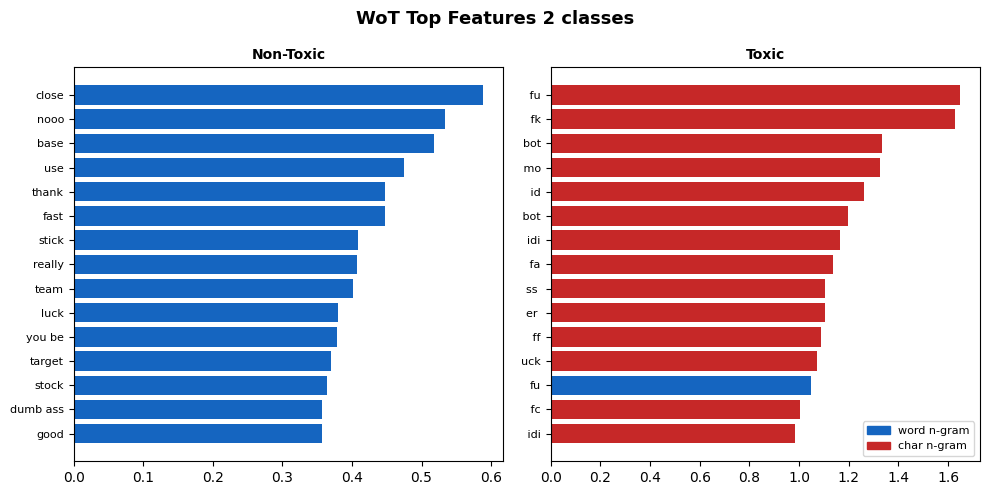

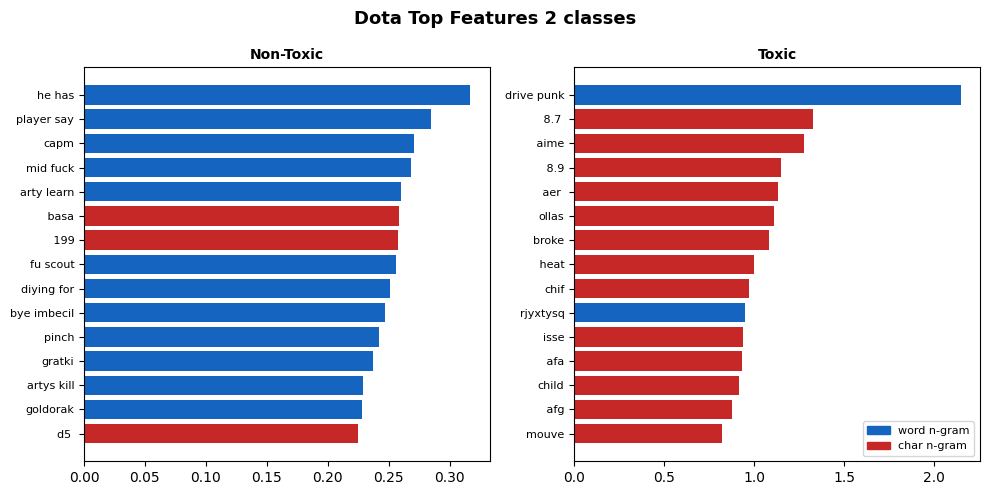

In [27]:
# fit 
train_df = load_wot('train').copy()
train_df[CONFIG['label_col']] = (train_df[CONFIG['label_col']].astype(int) > 0).astype(int)
X_tr = train_df[CONFIG['text_col']]
y_tr = train_df[CONFIG['label_col']]

wot_best_pipe.fit(X_tr, y_tr)
print(wot_best_pipe.named_steps['clf'].coef_.shape)

def plot_top_features(pipe, class_names: list, title: str, top_n: int = 15):
    from matplotlib.patches import Patch

    tfidf = pipe.named_steps['tfidf']
    clf   = pipe.named_steps['clf']

    # FeatureUnion.get_feature_names_out() buggy in some sklearn versions — build manually
    if hasattr(tfidf, 'transformer_list'):
        raw_names = np.concatenate([
            np.array([f'{name}__{n}' for n in tr.get_feature_names_out()])
            for name, tr in tfidf.transformer_list
        ])
    else:
        raw_names = np.array(tfidf.get_feature_names_out())

    is_char = np.array([n.startswith('char__') for n in raw_names])
    display_names = np.array([n.split('__', 1)[-1]   for n in raw_names])

    coef = clf.coef_ if hasattr(clf, 'coef_') else clf.feature_log_prob_
    if coef.shape[0] == 1:
        coef = np.vstack([-coef, coef])

    n_cls = len(class_names)
    fig, axes = plt.subplots(1, n_cls, figsize=(5 * n_cls, 5))
    if n_cls == 1:
        axes = [axes]

    for ax, cls_idx, cls_name in zip(axes, range(n_cls), class_names):
        top_idx = np.argsort(coef[cls_idx])[-top_n:][::-1]
        colors  = ['#C62828' if is_char[i] else '#1565C0' for i in top_idx[::-1]]
        ax.barh(display_names[top_idx][::-1], coef[cls_idx][top_idx][::-1], color=colors)
        ax.set_title(cls_name, fontsize=10, fontweight='bold')
        ax.tick_params(axis='y', labelsize=8)

    legend = [Patch(color='#1565C0', label='word n-gram'),
              Patch(color='#C62828', label='char n-gram')]
    axes[-1].legend(handles=legend, loc='lower right', fontsize=8)

    plt.suptitle(title, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()



# plot the features 
plot_top_features(wot_best_pipe,  WOT_CLASS_NAMES[wot_best_n],
                  f'WoT Top Features {wot_best_n} classes')
plot_top_features(dota_best_pipe, DOTA_CLASS_NAMES[dota_best_n],
                  f'Dota Top Features {dota_best_n} classes')


## Section 5: Combined Testing

In [32]:
# combined data fine-tuning 
print('\n=== Combined model selection ===')
combined_compare_df, combined_pipes = run_model_selection('Combined', load_combined, 2)

combined_best_model_name = combined_compare_df.iloc[0]['Model']
print(f'\nBest: Combined={combined_best_model_name}')


=== Combined model selection ===
[Combined] Logistic Regression ...
[Combined] Naive Bayes (Optuna) ...
[Combined] LinearSVC (Optuna) ...

Combined model comparison:
              Model  cv_f1  cv_f1_std  cv_recall  cv_precision
          LinearSVC 0.7777     0.0063     0.7630        0.7931
Logistic Regression 0.7499     0.0091     0.7381        0.7623
        Naive Bayes 0.7082     0.0062     0.7830        0.6466

Best: Combined=LinearSVC


In [35]:
# fit once on combined train, evaluate on combined val
combined_best_pipe = evaluate_best(
    'Combined', combined_best_model_name, combined_pipes, load_combined,
    2, ['Non-Toxic', 'Toxic'], combined_compare_df,
    ood_load_fn=None
)

# evaluate already-fitted pipe on each game val — no refit
def load_val_binary(load_fn):
    df = load_fn('val').copy()
    df[CONFIG['label_col']] = (df[CONFIG['label_col']].astype(int) > 0).astype(int)
    return df[CONFIG['text_col']], df[CONFIG['label_col']]

# world of tanks 
X_wot_val,  y_wot_val  = load_val_binary(load_wot)

# dota 
X_dota_val, y_dota_val = load_val_binary(load_dota)

# combined dataset predictions on world of tanks
print('\n=== Combined -> WoT ===')
print(classification_report(y_wot_val,  combined_best_pipe.predict(X_wot_val),
                             target_names=['Non-Toxic', 'Toxic'], zero_division=0))

# combined dataset predictions on dota
print('\n=== Combined -> Dota ===')
print(classification_report(y_dota_val, combined_best_pipe.predict(X_dota_val),
                             target_names=['Non-Toxic', 'Toxic'], zero_division=0))


=== Combined LinearSVC - in-game test ===
              precision    recall  f1-score   support

   Non-Toxic       0.93      0.94      0.93     11257
       Toxic       0.78      0.76      0.77      3234

    accuracy                           0.90     14491
   macro avg       0.85      0.85      0.85     14491
weighted avg       0.90      0.90      0.90     14491


=== Combined -> WoT ===
              precision    recall  f1-score   support

   Non-Toxic       0.94      0.95      0.94      6779
       Toxic       0.77      0.74      0.75      1564

    accuracy                           0.91      8343
   macro avg       0.85      0.84      0.85      8343
weighted avg       0.91      0.91      0.91      8343


=== Combined -> Dota ===
              precision    recall  f1-score   support

   Non-Toxic       0.92      0.92      0.92      4478
       Toxic       0.79      0.78      0.79      1670

    accuracy                           0.88      6148
   macro avg       0.85      0.85  